In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics 
import seaborn as sn

In [19]:
col_names=['sno','gre','toefl','rating','sop','lor','cg','research','chance']
df = pd.read_csv('/kaggle/input/datasets/mohansacharya/graduate-admissions/Admission_Predict.csv', header=None, skiprows=1, names=col_names)
print(df.head(), "\n\n\n\n")
print(df.columns)

   sno  gre  toefl  rating  sop  lor    cg  research  chance
0    1  337    118       4  4.5  4.5  9.65         1    0.92
1    2  324    107       4  4.0  4.5  8.87         1    0.76
2    3  316    104       3  3.0  3.5  8.00         1    0.72
3    4  322    110       3  3.5  2.5  8.67         1    0.80
4    5  314    103       2  2.0  3.0  8.21         0    0.65 




Index(['sno', 'gre', 'toefl', 'rating', 'sop', 'lor', 'cg', 'research',
       'chance'],
      dtype='object')


In [20]:
df.isnull().sum()

sno         0
gre         0
toefl       0
rating      0
sop         0
lor         0
cg          0
research    0
chance      0
dtype: int64

In [32]:
feat_cols=['gre','toefl','rating','sop','lor','cg','research']
x=df[feat_cols]
y = (df['chance'] >= 0.75).astype(int) #Categorising >=75percent as 1 since logistic regr expects categorical and not continuous value 
print(x, '\n\n\n\n')
print(y)

     gre  toefl  rating  sop  lor    cg  research
0    337    118       4  4.5  4.5  9.65         1
1    324    107       4  4.0  4.5  8.87         1
2    316    104       3  3.0  3.5  8.00         1
3    322    110       3  3.5  2.5  8.67         1
4    314    103       2  2.0  3.0  8.21         0
..   ...    ...     ...  ...  ...   ...       ...
395  324    110       3  3.5  3.5  9.04         1
396  325    107       3  3.0  3.5  9.11         1
397  330    116       4  5.0  4.5  9.45         1
398  312    103       3  3.5  4.0  8.78         0
399  333    117       4  5.0  4.0  9.66         1

[400 rows x 7 columns] 




0      1
1      1
2      0
3      1
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: chance, Length: 400, dtype: int64


In [33]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size=0.2,random_state=42)
display(xtrain.shape,xtest.shape,ytrain.shape,ytest.shape)

(320, 7)

(80, 7)

(320,)

(80,)

In [34]:
mdl = LogisticRegression(solver='lbfgs', max_iter=1000)

In [35]:
mdl.fit(xtrain,ytrain)
ypred=mdl.predict(xtest)

In [36]:
conf_mat=metrics.confusion_matrix(ytest,ypred)
print('Confusion Matrix: ',conf_mat)
acc_score=metrics.accuracy_score(ytest,ypred)
print('Accuracy: ',acc_score)
print('Accuracy in percentage: ',int(acc_score*100),'%')

Confusion Matrix:  [[43  4]
 [ 2 31]]
Accuracy:  0.925
Accuracy in percentage:  92 %


<Axes: xlabel='Predicted', ylabel='Actual'>

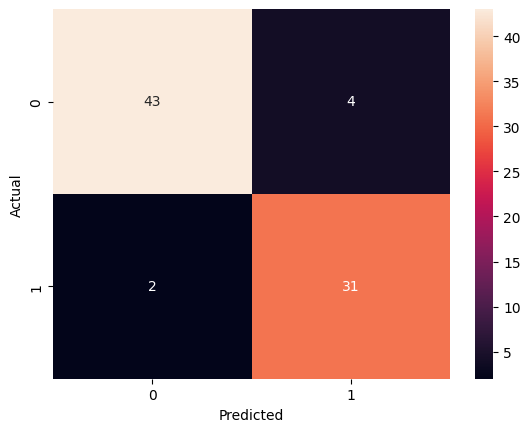

In [37]:
conf_mat=pd.crosstab(ytest,ypred,rownames=['Actual'],colnames=['Predicted'])
sn.heatmap(conf_mat, annot=True)